In [3]:
import pandas as pd
import json

# Load one JSON file
with open("C:\\Users\\saura\\Downloads\\15956.json", "r") as f:
    data = json.load(f)

# Convert JSON to DataFrame
df = pd.json_normalize(data)

# Show first 5 rows
print(df.head())
# Check the structure of your dataset
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns[:20])  # first 20 column names
print("\nData types:\n", df.dtypes[:10])  # check first 10 columns' data types

# Count how many events of each type exist
event_counts = df['type.name'].value_counts()
print("\nEvent type counts:\n", event_counts)

# View the top players involved in events
if 'player.name' in df.columns:
    print("\nTop players by event count:")
    print(df['player.name'].value_counts().head(10))



                                     id  index  period     timestamp  minute  \
0  2bb933a9-8a0b-4cbf-8c8c-fa40816ed359      1       1  00:00:00.000       0   
1  e4327a98-e4c9-4134-9f0f-ea1ef5dd5c41      2       1  00:00:00.000       0   
2  3b5a4f64-ec95-419b-b6b1-54c70f2605fa      3       1  00:00:00.000       0   
3  28abce03-2a0c-4af0-b3a2-e948f34e04d6      4       1  00:00:00.000       0   
4  e903210f-74f2-4b9c-8169-e717645be161      5       1  00:00:00.857       0   

   second  possession  duration  type.id    type.name  ...  \
0       0           1  0.000000       35  Starting XI  ...   
1       0           1  0.000000       35  Starting XI  ...   
2       0           1  0.000000       18   Half Start  ...   
3       0           1  0.000000       18   Half Start  ...   
4       0           2  0.914418       30         Pass  ...   

   foul_committed.card.name foul_committed.type.id  foul_committed.type.name  \
0                       NaN                    NaN                

In [5]:
import pandas as pd

# Step 1: Load dataset
df = pd.read_csv(r"C:\Users\saura\Downloads\archive\players.csv")
print("✅ Data loaded successfully!")
print("Shape:", df.shape)
print(df.head())

# Step 2: Check columns
print("\n🧩 Available columns:")
print(df.columns.tolist())

# Step 3: Handle missing values and ensure correct column names
# Try to identify the correct market value column
if "market_value_in_eur" in df.columns:
    value_col = "market_value_in_eur"
elif "value_eur" in df.columns:
    value_col = "value_eur"
elif "value" in df.columns:
    value_col = "value"
else:
    raise KeyError("⚠️ Could not find a market value column in the dataset.")

# Step 4: Drop rows with missing values in that column
df = df.dropna(subset=[value_col])

# Step 5: Convert to numeric
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

# Step 6: Find the top 10 players by market value
cols_to_show = [col for col in ["name", "position", "club", value_col] if col in df.columns]
top_players = df.sort_values(value_col, ascending=False).head(10)
print("\n💰 Top 10 Players by Market Value:")
print(top_players[cols_to_show])

# Step 7: Save cleaned dataset
df.to_csv("transfermarkt_clean.csv", index=False, encoding="utf-8")
print("\n✅ transfermarkt_clean.csv saved — ready for analysis!")



✅ Data loaded successfully!
Shape: (32601, 23)
   player_id first_name     last_name                name  last_season  \
0         10   Miroslav         Klose      Miroslav Klose         2015   
1         26      Roman  Weidenfeller  Roman Weidenfeller         2017   
2         65    Dimitar      Berbatov    Dimitar Berbatov         2015   
3         77        NaN         Lúcio               Lúcio         2012   
4         80        Tom        Starke          Tom Starke         2017   

   current_club_id         player_code    country_of_birth city_of_birth  \
0              398      miroslav-klose              Poland         Opole   
1               16  roman-weidenfeller             Germany          Diez   
2             1091    dimitar-berbatov            Bulgaria   Blagoevgrad   
3              506               lucio              Brazil      Brasília   
4               27          tom-starke  East Germany (GDR)       Freital   

  country_of_citizenship  ...   foot height_in_cm c

✅ Dataset loaded!
Index(['Unnamed: 0', 'Date Created', 'Number of Likes', 'Source of Tweet',
       'Tweet', 'Sentiment'],
      dtype='object')

📊 Sentiment Summary:
Label
Neutral     11323
Positive     8505
Negative     2696
Name: count, dtype: int64


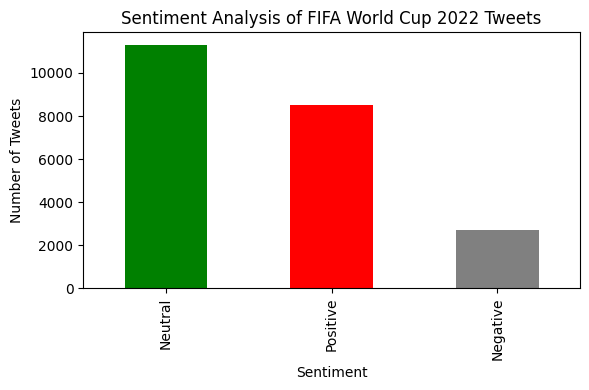


✅ Saved: fifa_world_cup_2022_sentiment.csv


In [11]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load the Kaggle dataset
df = pd.read_csv(r"C:\\Users\\saura\\Project\\fifa_world_cup_2022_tweets.csv")

print("✅ Dataset loaded!")
print(df.columns)

# ✅ Correct column name
text_col = "Tweet"

# Drop missing rows
df = df.dropna(subset=[text_col])

# Sentiment functions
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

def classify(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df["Sentiment"] = df[text_col].apply(get_sentiment)
df["Label"] = df["Sentiment"].apply(classify)

# Summary
print("\n📊 Sentiment Summary:")
print(df["Label"].value_counts())

# Visualization
plt.figure(figsize=(6,4))
df["Label"].value_counts().plot(kind="bar", color=["green", "red", "gray"])
plt.title("Sentiment Analysis of FIFA World Cup 2022 Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

# Save results
df.to_csv("fifa_world_cup_2022_sentiment.csv", index=False, encoding="utf-8")
print("\n✅ Saved: fifa_world_cup_2022_sentiment.csv")




In [15]:
import pandas as pd

# Load dataset
df = pd.read_csv("transfermarkt_clean.csv")

print("✅ Dataset loaded successfully!")
print(df.info())
print(df.head())

# Check missing data
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Drop columns with too many missing values (e.g., >50%)
df = df.dropna(thresh=len(df)*0.5, axis=1)

# Fill missing numeric values with mean
df = df.fillna(df.mean(numeric_only=True))

# Fill missing categorical data with 'Unknown'
df = df.fillna('Unknown')

# Remove duplicate rows
df = df.drop_duplicates()

# Detect and handle outliers in numeric data (optional)
for col in df.select_dtypes(include='number'):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

# print(df.columns)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["position_encoded"] = encoder.fit_transform(df["position"].astype(str))
df["club_encoded"] = encoder.fit_transform(df["current_club_name"].astype(str))


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ["height_in_cm", "market_value_in_eur"]
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.to_csv("transfermarkt_preprocessed.csv", index=False)
print("✅ transfermarkt_preprocessed.csv saved successfully!")

import pandas as pd

df = pd.read_csv("fifa_world_cup_2022_sentiment.csv")

# Check missing values
print(df.isnull().sum())

# Drop missing text rows
df = df.dropna(subset=["Tweet"])

# Remove duplicates
df = df.drop_duplicates(subset=["Tweet"])

# Clean text (optional)
df["Tweet"] = df["Tweet"].str.lower().str.replace(r"http\S+|www\S+|[^a-zA-Z\s]", "", regex=True)

# Save cleaned version
df.to_csv("fifa_world_cup_2022_sentiment_clean.csv", index=False)
print("✅ Cleaned FIFA sentiment file saved!")


✅ Dataset loaded successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31078 entries, 0 to 31077
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             31078 non-null  int64  
 1   first_name                            29059 non-null  object 
 2   last_name                             31078 non-null  object 
 3   name                                  31078 non-null  object 
 4   last_season                           31078 non-null  int64  
 5   current_club_id                       31078 non-null  int64  
 6   player_code                           31078 non-null  object 
 7   country_of_birth                      28918 non-null  object 
 8   city_of_birth                         29250 non-null  object 
 9   country_of_citizenship                30715 non-null  object 
 10  date_of_birth                         31046 non-nul